# 📈 월간 수익률 랭킹 예측 및 포트폴리오 전략 모델

**목표**: 월말 Feature Panel → t+3개월 alpha_3m 예측 → 상위 20% 포트폴리오 구성

| 섹션 | 내용 |
|------|------|
| Cell 1 | 라이브러리 임포트 및 설정 |
| Cell 2 | Synthetic 데이터 생성 |
| Cell 3 | `AlphaModelPipeline` 클래스 정의 |
| Cell 4 | 실행 및 결과 출력 |

---
## Cell 1 — 라이브러리 임포트 및 전역 설정

In [15]:
# ─────────────────────────────────────────────────────────────────────
# Cell 1  라이브러리 임포트 및 전역 설정
# ─────────────────────────────────────────────────────────────────────
import warnings, itertools
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    classification_report, roc_auc_score
)
from sklearn.preprocessing import RobustScaler

import lightgbm as lgb
import xgboost as xgb

# ── 전역 시드 고정 ──────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── 플롯 스타일 ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('husl')

print('✅ Cell 1 완료 — 라이브러리 로드 성공')

✅ Cell 1 완료 — 라이브러리 로드 성공


---
## Cell 2 — Synthetic 데이터 생성
> 실제 데이터가 없을 때 파이프라인 검증용으로 사용합니다.

In [17]:
# ─────────────────────────────────────────────────────────────────────
# Cell 2  Synthetic 월말 Panel 데이터 생성
# ─────────────────────────────────────────────────────────────────────
def make_synthetic_panel(
    n_tickers: int = 2000,
    start: str   = '2018-01-31',
    end: str     = '2025-12-31',
    random_state: int = 42,
) -> pd.DataFrame:
    """
    월말 기준 Panel DataFrame 생성.

    컬럼:
        date, ticker, sector, price,
        market_return (SPY 월간 로그수익률),
        Price/Technical: ret_1m ~ price_to_ma120, rel_ret_spy_3m,
        Macro: vix, term_spread_10y_2y, oas_spread, us10y_yield, dxy,
        Commodity: wti_ret_1m, copper_ret_1m, gold_ret_1m,
        Fundamental: sales_growth_yoy, eps_growth_yoy, roe,
                     operating_margin, debt_to_equity,
        Valuation: pbr_sector_z, psr_sector_z, per_sector_z, ev_ebitda_sector_z
    """
    rng     = np.random.default_rng(random_state)
    dates   = pd.date_range(start, end, freq='ME')   # 월말 날짜
    sectors = ['Technology','Health Care','Financials',
               'Consumer Discretionary','Industrials','Energy']
    tickers = [f'T{str(i).zfill(4)}' for i in range(n_tickers)]
    ticker_sector = {t: sectors[i % len(sectors)] for i, t in enumerate(tickers)}

    rows = []
    # ── 매크로 / 원자재는 날짜별 단일 값 ────────────────────────────
    macro_by_date = {
        d: {
            'market_return'      : float(rng.normal(0.005, 0.035)),
            'vix'                : float(rng.uniform(12, 40)),
            'term_spread_10y_2y' : float(rng.normal(0.5, 0.8)),
            'oas_spread'         : float(rng.uniform(2.5, 6.5)),
            'us10y_yield'        : float(rng.uniform(1.0, 5.0)),
            'dxy'                : float(rng.normal(100, 6)),
            'wti_ret_1m'         : float(rng.normal(0.0, 0.08)),
            'copper_ret_1m'      : float(rng.normal(0.0, 0.06)),
            'gold_ret_1m'        : float(rng.normal(0.0, 0.04)),
        }
        for d in dates
    }

    for ticker in tickers:
        sec   = ticker_sector[ticker]
        price = float(rng.uniform(10, 500))   # 초기 가격
        for d in dates:
            m_ret     = macro_by_date[d]['market_return']
            stk_alpha = float(rng.normal(0, 0.03))
            price    *= np.exp(m_ret + stk_alpha)
            row = {'date': d, 'ticker': ticker, 'sector': sec, 'price': price}
            row.update(macro_by_date[d])
            # ── Price/Technical ────────────────────────────────────
            row['ret_1m']          = float(rng.normal(m_ret, 0.04))
            row['ret_3m']          = row['ret_1m'] * 3 + float(rng.normal(0, 0.02))
            row['ret_6m']          = row['ret_3m'] * 2 + float(rng.normal(0, 0.03))
            row['ret_12m']         = row['ret_6m'] * 2 + float(rng.normal(0, 0.04))
            row['vol_20d']         = float(rng.uniform(0.10, 0.60))
            row['vol_60d']         = row['vol_20d'] * float(rng.uniform(0.8, 1.2))
            row['downside_vol_60d']= row['vol_60d'] * float(rng.uniform(0.5, 0.9))
            row['price_to_ma20']   = float(rng.normal(0.0, 0.05))
            row['price_to_ma60']   = float(rng.normal(0.0, 0.08))
            row['price_to_ma120']  = float(rng.normal(0.0, 0.10))
            row['rel_ret_spy_3m']  = row['ret_3m'] - m_ret * 3
            # ── Fundamental (일부 결측 도입) ───────────────────────
            row['sales_growth_yoy']  = float(rng.normal(0.08, 0.15)) if rng.random() > 0.05 else np.nan
            row['eps_growth_yoy']    = float(rng.normal(0.10, 0.25)) if rng.random() > 0.05 else np.nan
            row['roe']               = float(rng.uniform(0.02, 0.35)) if rng.random() > 0.05 else np.nan
            row['operating_margin']  = float(rng.uniform(0.03, 0.30)) if rng.random() > 0.05 else np.nan
            row['debt_to_equity']    = float(rng.uniform(0.0, 3.0))   if rng.random() > 0.05 else np.nan
            # ── Valuation (섹터 Z-Score 형태) ─────────────────────
            row['pbr_sector_z']       = float(rng.normal(0, 1))
            row['psr_sector_z']       = float(rng.normal(0, 1))
            row['per_sector_z']       = float(rng.normal(0, 1))
            row['ev_ebitda_sector_z'] = float(rng.normal(0, 1))
            rows.append(row)

    df = pd.DataFrame(rows).sort_values(['date','ticker']).reset_index(drop=True)
    print(f'✅ Synthetic Panel 생성: {df.shape[0]:,}행 × {df.shape[1]}열')
    print(f'   기간: {df.date.min().date()} ~ {df.date.max().date()}')
    print(f'   종목: {n_tickers}개  |  월: {df.date.nunique()}개  |  섹터: {len(sectors)}개')
    return df


# ── 데이터 생성 ───────────────────────────────────────────────────────
# ★ 여기서 n_tickers를 조절하세요 (실제 데이터 사용 시 이 셀을 건너뜁니다)
N_TICKERS = 2000
df_raw = make_synthetic_panel(n_tickers=N_TICKERS, start='2018-01-31', end='2024-12-31')
df_raw.head(3)

✅ Synthetic Panel 생성: 168,000행 × 33열
   기간: 2018-01-31 ~ 2024-12-31
   종목: 2000개  |  월: 84개  |  섹터: 6개


,date,ticker,sector,price,market_return,vix,term_spread_10y_2y,oas_spread,us10y_yield,dxy,...,rel_ret_spy_3m,sales_growth_yoy,eps_growth_yoy,roe,operating_margin,debt_to_equity,pbr_sector_z,psr_sector_z,per_sector_z,ev_ebitda_sector_z
0,2018-01-31,T0000,Technology,135.492141,0.015665,24.288596,1.100361,5.289472,1.376709,92.186923,...,-0.080833,0.175536,NaN,0.026281,0.225799,2.215741,1.359221,0.255213,1.350625,0.012053
1,2018-01-31,T0001,Health Care,178.406643,0.015665,24.288596,1.100361,5.289472,1.376709,92.186923,...,-0.178910,0.227101,-0.148923,0.146704,0.070291,1.137375,-0.167874,1.096064,0.580396,0.731813
2,2018-01-31,T0002,Financials,306.119953,0.015665,24.288596,1.100361,5.289472,1.376709,92.186923,...,-0.059518,-0.140086,-0.108399,0.187160,0.192229,2.758420,-2.082241,0.070590,0.025770,0.182929


---
## Cell 3 — `AlphaModelPipeline` 클래스 정의

In [18]:
# ─────────────────────────────────────────────────────────────────────
# Cell 3  AlphaModelPipeline 클래스
# ─────────────────────────────────────────────────────────────────────

class AlphaModelPipeline:
    """
    월간 수익률 랭킹 예측 및 포트폴리오 전략 파이프라인.

    주요 메서드:
        preprocess()        → 결측치 처리, lag 처리, 타겟 생성
        run_walkforward()   → Walk-forward 학습/예측
        backtest()          → 포트폴리오 백테스트
        evaluate()          → 성과 지표 출력
        plot_results()      → 누적수익률 그래프
        run()               → 전체 파이프라인 실행 (원스톱)
    """

    # ── Feature 그룹 정의 ─────────────────────────────────────────────
    PRICE_TECH_COLS = [
        'ret_1m','ret_3m','ret_6m','ret_12m',
        'vol_20d','vol_60d','downside_vol_60d',
        'price_to_ma20','price_to_ma60','price_to_ma120',
        'rel_ret_spy_3m',
    ]
    MACRO_COLS = [
        'vix','term_spread_10y_2y','oas_spread','us10y_yield','dxy',
    ]
    COMMODITY_COLS = [
        'wti_ret_1m','copper_ret_1m','gold_ret_1m',
    ]
    FUNDAMENTAL_COLS = [
        'sales_growth_yoy','eps_growth_yoy','roe',
        'operating_margin','debt_to_equity',
    ]
    VALUATION_COLS = [
        'pbr_sector_z','psr_sector_z','per_sector_z','ev_ebitda_sector_z',
    ]

    def __init__(
        self,
        n_tickers:        int   = 200,
        horizon:          int   = 3,          # 예측 horizon (개월)
        top_pct:          float = 0.20,        # 상위 몇 % 를 positive class로
        min_train_months: int   = 36,          # 최소 학습 기간 (개월)
        model_type:       str   = 'lgbm',      # 'lgbm' 또는 'xgb'
        transaction_cost: float = 0.001,       # 편도 거래비용 (10bp)
        random_state:     int   = 42,
    ):
        self.n_tickers        = n_tickers
        self.horizon          = horizon
        self.top_pct          = top_pct
        self.min_train_months = min_train_months
        self.model_type       = model_type
        self.transaction_cost = transaction_cost
        self.random_state     = random_state

        # 결과 저장소
        self.df_panel_       = None   # 전처리 + 타겟 완성 panel
        self.df_predictions_ = None   # walk-forward 예측 결과
        self.df_portfolio_   = None   # 월별 포트폴리오 수익률
        self.feature_cols_   = None   # 실제 사용 feature 컬럼
        self.models_         = {}     # {date: fitted_model}

    # ═══════════════════════════════════════════════════════════════════
    # 1. 전처리
    # ═══════════════════════════════════════════════════════════════════
    def preprocess(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        전처리 파이프라인:
          1) price / macro / commodity → ticker별 forward-fill (최대 3개월)
          2) fundamental / valuation  → (date, sector) 중앙값 대체 + missing indicator
          3) look-ahead bias 방지: feature에 1기 lag 적용 (t-1 값 → t 시점 사용)
          4) alpha_3m 타겟 생성 및 5분위 레이블 + binary target_top20_3m 생성
        """
        print('▶ [전처리] 시작...')
        df = df.copy()
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values(['ticker','date']).reset_index(drop=True)

        # ── (a) 필요한 컬럼 존재 여부 확인 & 없으면 0으로 패딩 ──────
        all_feat_cols = (
            self.PRICE_TECH_COLS + self.MACRO_COLS +
            self.COMMODITY_COLS  + self.FUNDAMENTAL_COLS +
            self.VALUATION_COLS
        )
        for c in all_feat_cols:
            if c not in df.columns:
                df[c] = np.nan
                print(f'  ⚠️  {c} 컬럼 없음 → NaN으로 추가')

        # ── (b) Price/Macro/Commodity: ticker 기준 forward fill (최대 3개월) ─
        ffill_cols = [
            c for c in self.PRICE_TECH_COLS + self.MACRO_COLS + self.COMMODITY_COLS
            if c in df.columns
        ]
        df[ffill_cols] = (
            df.groupby('ticker')[ffill_cols]
              .transform(lambda x: x.ffill(limit=3))
        )

        # ── (c) Fundamental/Valuation: (date, sector) 중앙값 대체 + missing indicator ─
        fund_val_cols = [
            c for c in self.FUNDAMENTAL_COLS + self.VALUATION_COLS
            if c in df.columns
        ]
        for c in self.FUNDAMENTAL_COLS:
            if c in df.columns:
                indicator_col = f'{c}_missing'
                df[indicator_col] = df[c].isna().astype(int)
        df[fund_val_cols] = (
            df.groupby(['date','sector'])[fund_val_cols]
              .transform(lambda x: x.fillna(x.median()))
        )
        # 섹터 중앙값으로도 채워지지 않은 경우 전체 중앙값으로 최종 대체
        df[fund_val_cols] = df[fund_val_cols].fillna(df[fund_val_cols].median())

        # ── (d) look-ahead bias 방지: feature에 1기 lag 적용 ──────────
        #   각 feature를 ticker 내에서 1개월 shift → t 시점에서 t-1 값 사용
        lag_cols = all_feat_cols + [
            f'{c}_missing' for c in self.FUNDAMENTAL_COLS if f'{c}_missing' in df.columns
        ]
        for c in lag_cols:
            if c in df.columns:
                df[c] = df.groupby('ticker')[c].shift(1)

        # ── (e) 타겟 생성 ────────────────────────────────────────────
        df = self._create_target(df)

        # ── (f) feature 컬럼 목록 확정 (missing indicator 포함) ──────
        missing_ind_cols = [c for c in df.columns if c.endswith('_missing')]
        self.feature_cols_ = [
            c for c in all_feat_cols + missing_ind_cols
            if c in df.columns
        ]

        # ── (g) 타겟 & feature가 모두 있는 행만 유지 ─────────────────
        df = df.dropna(subset=['target_top20_3m'])
        df = df.dropna(subset=self.feature_cols_, how='all')
        df = df.reset_index(drop=True)

        self.df_panel_ = df
        print(f'  → 전처리 완료: {df.shape[0]:,}행  피처 수: {len(self.feature_cols_)}개')
        print(f'  → 유효 날짜 범위: {df.date.min().date()} ~ {df.date.max().date()}')
        return df

    # ─── 타겟 생성 헬퍼 ────────────────────────────────────────────────
    def _create_target(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        1. 종목별 t+3개월 누적 로그수익률 계산
        2. 벤치마크(market_return) t+3개월 누적 차감 → alpha_3m
        3. 월별 5분위 그룹 (quintile_3m)
        4. 상위 20% → target_top20_3m = 1
        """
        h = self.horizon
        df = df.sort_values(['ticker','date']).copy()

        # t+h개월 후 가격으로 누적 로그수익률
        df['price_fwd'] = df.groupby('ticker')['price'].shift(-h)
        df['ret_fwd_h'] = np.log(df['price_fwd'] / df['price'])

        # 벤치마크 t+h 누적 로그수익률 (market_return이 월간이면 h개월 합산)
        if 'market_return' in df.columns:
            df['mkt_fwd_h'] = (
                df.sort_values(['date'])
                  .groupby('ticker')['market_return']
                  .transform(lambda x: x.rolling(h).sum().shift(-h+1))
                  # 참고: rolling(h).sum() at t = t-h+1 ~ t의 합 → shift로 맞춤
            )
            # 더 정확한 방법: 날짜별 market_return 합산 후 merge
            mkt_df = (
                df[['date','market_return']].drop_duplicates('date')
                   .sort_values('date').reset_index(drop=True)
            )
            mkt_cumsum = []
            for i, row in mkt_df.iterrows():
                future_rets = mkt_df.loc[
                    (mkt_df['date'] > row['date']) &
                    (mkt_df['date'] <= row['date'] + pd.DateOffset(months=h)),
                    'market_return'
                ]
                mkt_cumsum.append(future_rets.sum() if len(future_rets) > 0 else np.nan)
            mkt_df['mkt_fwd_h'] = mkt_cumsum
            df = df.drop(columns=['mkt_fwd_h'], errors='ignore')
            df = df.merge(mkt_df[['date','mkt_fwd_h']], on='date', how='left')
        else:
            df['mkt_fwd_h'] = 0.0

        df['alpha_3m'] = df['ret_fwd_h'] - df['mkt_fwd_h']

        # 월별 5분위 (look-ahead: alpha는 미래값이므로 타겟 생성에만 사용)
        def quintile_label(x):
            try:
                return pd.qcut(x, q=5, labels=[1,2,3,4,5])
            except Exception:
                return pd.Series(np.nan, index=x.index)

        df['quintile_3m']    = df.groupby('date')['alpha_3m'].transform(quintile_label)
        df['target_top20_3m']= (df['quintile_3m'] == 5).astype(float)

        return df

    # ═══════════════════════════════════════════════════════════════════
    # 2. Walk-forward 학습/예측
    # ═══════════════════════════════════════════════════════════════════
    def run_walkforward(self) -> pd.DataFrame:
        """
        Walk-forward validation:
          - 최소 36개월 학습 후 매월 1회 재학습 + 1회 예측
          - 결과: date, ticker, proba, pred, realized_alpha_3m
        """
        assert self.df_panel_ is not None, '先 preprocess() 호출 필요'
        print('▶ [Walk-forward] 시작...')

        df       = self.df_panel_
        all_dates= sorted(df['date'].unique())
        feat_cols= self.feature_cols_
        records  = []

        for i, pred_date in enumerate(all_dates):
            train_dates = [d for d in all_dates if d < pred_date]
            if len(train_dates) < self.min_train_months:
                continue

            df_train = df[df['date'].isin(train_dates)].copy()
            df_pred  = df[df['date'] == pred_date].copy()

            if df_train['target_top20_3m'].nunique() < 2:
                continue
            if df_pred.empty:
                continue

            # ── 피처 행렬 준비 ──────────────────────────────────────
            X_train = df_train[feat_cols].fillna(0).values
            y_train = df_train['target_top20_3m'].values.astype(int)
            X_pred  = df_pred[feat_cols].fillna(0).values

            # ── 스케일링 (LightGBM/XGB는 트리 기반이라 필수는 아니나 일관성 유지) ─
            scaler  = RobustScaler()
            X_train = scaler.fit_transform(X_train)
            X_pred  = scaler.transform(X_pred)

            # ── 모델 학습 ────────────────────────────────────────────
            model = self._build_model(y_train)
            model.fit(X_train, y_train)
            self.models_[pred_date] = model

            # ── 예측 ─────────────────────────────────────────────────
            proba = model.predict_proba(X_pred)[:, 1]
            pred  = (proba >= 0.5).astype(int)

            for j, (_, row) in enumerate(df_pred.iterrows()):
                records.append({
                    'date'             : pred_date,
                    'ticker'           : row['ticker'],
                    'sector'           : row['sector'],
                    'proba'            : float(proba[j]),
                    'pred'             : int(pred[j]),
                    'actual'           : int(row['target_top20_3m']),
                    'realized_alpha_3m': row['alpha_3m'],
                    'price'            : row['price'],
                })

            n_pos = y_train.sum()
            print(f'  [{pred_date.date()}] 학습:{len(df_train):,}행(+:{n_pos}) '
                  f'→ 예측:{len(df_pred)}종목  AUC={self._quick_auc(y_train, model.predict_proba(X_train)[:,1]):.3f}')

        self.df_predictions_ = pd.DataFrame(records)
        print(f'\n  ✅ Walk-forward 완료: {len(self.df_predictions_):,}건 예측')
        return self.df_predictions_

    def _build_model(self, y_train: np.ndarray):
        """모델 인스턴스 생성 (class imbalance 자동 처리)"""
        pos   = int(y_train.sum())
        neg   = int(len(y_train) - pos)
        ratio = neg / max(pos, 1)   # scale_pos_weight 용

        if self.model_type == 'lgbm':
            return lgb.LGBMClassifier(
                n_estimators      = 200,
                max_depth         = 4,
                learning_rate     = 0.05,
                num_leaves        = 15,
                min_child_samples = 20,
                subsample         = 0.8,
                colsample_bytree  = 0.8,
                reg_alpha         = 0.1,
                reg_lambda        = 0.1,
                is_unbalance      = True,   # class imbalance 처리
                random_state      = self.random_state,
                verbose           = -1,
            )
        elif self.model_type == 'xgb':
            return xgb.XGBClassifier(
                n_estimators      = 200,
                max_depth         = 4,
                learning_rate     = 0.05,
                subsample         = 0.8,
                colsample_bytree  = 0.8,
                reg_alpha         = 0.1,
                reg_lambda        = 0.1,
                scale_pos_weight  = ratio,   # class imbalance 처리
                use_label_encoder = False,
                eval_metric       = 'logloss',
                random_state      = self.random_state,
                verbosity         = 0,
            )
        else:
            raise ValueError(f'model_type은 lgbm 또는 xgb 만 지원합니다. 입력값: {self.model_type}')

    @staticmethod
    def _quick_auc(y_true, y_score):
        """간단 AUC 계산 (오류 시 0.5 반환)"""
        try:
            return roc_auc_score(y_true, y_score)
        except Exception:
            return 0.5

    # ═══════════════════════════════════════════════════════════════════
    # 3. 포트폴리오 백테스트
    # ═══════════════════════════════════════════════════════════════════
    def backtest(self) -> pd.DataFrame:
        """
        Overlapping Portfolio 백테스트:
          - 매월 예측 확률로 종목 랭킹화
          - 상위 20%: 신규 매수 / 유지
          - 20~40%:  절반 축소
          - 40% 밖:  전량 매도
          - 동일가중, 거래비용 10bp 반영
        """
        assert self.df_predictions_ is not None, '先 run_walkforward() 호출 필요'
        print('\n▶ [백테스트] 시작...')

        pred     = self.df_predictions_.copy()
        dates    = sorted(pred['date'].unique())
        tc       = self.transaction_cost
        top_cut  = self.top_pct           # 상위 20%
        mid_cut  = self.top_pct * 2       # 20~40%

        # 현재 포트폴리오 가중치: {ticker: weight}
        portfolio_now: dict = {}
        monthly_records     = []

        for i, date in enumerate(dates[:-self.horizon]):  # 마지막 h개월은 실현수익률 없음
            df_t   = pred[pred['date'] == date].copy()
            n_t    = len(df_t)
            if n_t == 0:
                continue

            # ── 확률 기준 퍼센타일 랭킹 ────────────────────────────
            df_t['pct_rank'] = df_t['proba'].rank(pct=True, ascending=True)

            # ── 새 포트폴리오 구성 ──────────────────────────────────
            portfolio_new: dict = {}
            turnover_sell = 0.0
            turnover_buy  = 0.0

            # ① 기존 보유 종목 처리
            for ticker, w_old in portfolio_now.items():
                row = df_t[df_t['ticker'] == ticker]
                if row.empty:
                    # 예측 결과에 없음 → 전량 매도
                    turnover_sell += w_old
                    continue
                pct = float(row['pct_rank'].iloc[0])
                if pct >= (1 - top_cut):       # 상위 20% → 유지
                    portfolio_new[ticker] = w_old
                elif pct >= (1 - mid_cut):     # 20~40% → 절반 축소
                    portfolio_new[ticker] = w_old * 0.5
                    turnover_sell += w_old * 0.5
                else:                           # 40% 밖 → 전량 매도
                    turnover_sell += w_old

            # ② 신규 매수 대상: 상위 20%이고 아직 보유 안 한 종목
            top_tickers  = set(
                df_t[df_t['pct_rank'] >= (1 - top_cut)]['ticker'].tolist()
            )
            existing     = set(portfolio_new.keys())
            new_buys     = top_tickers - existing

            # ③ 동일가중 리밸런싱
            all_held = list(existing | new_buys)
            if len(all_held) == 0:
                portfolio_now = {}
                monthly_records.append({'date': date, 'port_ret': 0.0, 'bench_ret': 0.0,
                                        'n_stocks': 0, 'turnover': 0.0})
                continue

            target_w = 1.0 / len(all_held)
            for ticker in new_buys:
                portfolio_new[ticker] = target_w
                turnover_buy          += target_w
            # 기존 종목도 동일가중으로 재조정
            for ticker in existing:
                old_w = portfolio_new.get(ticker, 0)
                delta = abs(target_w - old_w)
                portfolio_new[ticker] = target_w
                turnover_sell        += max(0, old_w - target_w)
                turnover_buy         += max(0, target_w - old_w)

            # ④ 포트폴리오 수익률 계산 (다음 달 realized_alpha_3m 사용)
            port_ret   = 0.0
            bench_ret  = 0.0
            for ticker, w in portfolio_new.items():
                row = df_t[df_t['ticker'] == ticker]
                if not row.empty:
                    alpha = row['realized_alpha_3m'].iloc[0]
                    if pd.notna(alpha):
                        port_ret += w * alpha

            # ⑤ 거래비용 차감 (매수 + 매도 편도 각 tc)
            total_turnover = (turnover_buy + turnover_sell) / 2
            cost           = total_turnover * tc
            port_ret      -= cost

            # 벤치마크 수익률
            panel_date = self.df_panel_[self.df_panel_['date'] == date]
            if 'market_return' in panel_date.columns and not panel_date.empty:
                bench_ret = float(panel_date['market_return'].iloc[0]) * self.horizon

            monthly_records.append({
                'date'      : date,
                'port_ret'  : port_ret,
                'bench_ret' : bench_ret,
                'n_stocks'  : len(portfolio_new),
                'turnover'  : total_turnover,
            })
            portfolio_now = portfolio_new

        self.df_portfolio_ = pd.DataFrame(monthly_records)
        print(f'  ✅ 백테스트 완료: {len(self.df_portfolio_)}개월')
        return self.df_portfolio_

    # ═══════════════════════════════════════════════════════════════════
    # 4. 성과 평가
    # ═══════════════════════════════════════════════════════════════════
    def evaluate(self) -> dict:
        """
        예측 성능 + 포트폴리오 성과 지표 계산 및 출력.
        반환: metrics dict
        """
        assert self.df_predictions_ is not None, '先 run_walkforward() 호출 필요'
        assert self.df_portfolio_   is not None, '先 backtest() 호출 필요'
        print('\n' + '='*65)
        print('📊  성과 평가 리포트')
        print('='*65)

        pred = self.df_predictions_.dropna(subset=['actual','pred'])
        y    = pred['actual'].astype(int)
        yhat = pred['pred'].astype(int)
        prob = pred['proba']

        # ── (A) 분류 성능 ────────────────────────────────────────────
        prec = precision_score(y, yhat, zero_division=0)
        rec  = recall_score(y, yhat,    zero_division=0)
        f1   = f1_score(y, yhat,        zero_division=0)
        auc  = self._quick_auc(y, prob)

        print('\n[A] 분류 모델 성능')
        print(f'  Precision : {prec:.4f}')
        print(f'  Recall    : {rec:.4f}')
        print(f'  F1-Score  : {f1:.4f}')
        print(f'  ROC-AUC   : {auc:.4f}')
        print()
        print(classification_report(y, yhat, target_names=['Non-Top20','Top20'], zero_division=0))

        # ── (B) 포트폴리오 성과 ──────────────────────────────────────
        port = self.df_portfolio_.copy()
        r    = port['port_ret'].values
        b    = port['bench_ret'].values
        exc  = r - b          # 초과수익

        n_months = len(r)
        cagr     = np.exp(np.sum(r)) ** (12 / n_months) - 1 if n_months > 0 else 0
        b_cagr   = np.exp(np.sum(b)) ** (12 / n_months) - 1 if n_months > 0 else 0

        sharpe   = (np.mean(exc) / (np.std(exc) + 1e-10)) * np.sqrt(12)
        cumret   = np.cumsum(r)
        drawdown = cumret - np.maximum.accumulate(cumret)
        mdd      = float(np.min(drawdown))
        turnover = float(port['turnover'].mean())

        print('\n[B] 포트폴리오 성과')
        print(f'  CAGR (포트)    : {cagr:+.2%}')
        print(f'  CAGR (벤치)    : {b_cagr:+.2%}')
        print(f'  초과 CAGR      : {cagr - b_cagr:+.2%}')
        print(f'  Sharpe Ratio   : {sharpe:.3f}')
        print(f'  Max Drawdown   : {mdd:.2%}')
        print(f'  평균 Turnover  : {turnover:.2%}/월')
        print(f'  평균 보유 종목 : {port["n_stocks"].mean():.0f}개')
        print('='*65)

        metrics = dict(
            precision=prec, recall=rec, f1=f1, auc=auc,
            cagr=cagr, bench_cagr=b_cagr,
            sharpe=sharpe, mdd=mdd, turnover=turnover,
        )
        return metrics

    # ═══════════════════════════════════════════════════════════════════
    # 5. 시각화
    # ═══════════════════════════════════════════════════════════════════
    def plot_results(self) -> None:
        """누적수익률, 월별 초과수익, Feature Importance, 예측 분포 4개 패널 출력"""
        assert self.df_portfolio_   is not None, '先 backtest() 호출 필요'
        assert self.df_predictions_ is not None, '先 run_walkforward() 호출 필요'

        port  = self.df_portfolio_.copy()
        port['cum_port']  = port['port_ret'].cumsum()
        port['cum_bench'] = port['bench_ret'].cumsum()
        port['cum_exc']   = port['cum_port'] - port['cum_bench']

        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        fig.suptitle('Alpha Model Pipeline — 성과 분석', fontsize=14, fontweight='bold', y=1.01)

        # ── (1) 누적수익률 비교 ──────────────────────────────────────
        ax1 = axes[0, 0]
        ax1.plot(port['date'], port['cum_port'],  label='포트폴리오', linewidth=2, color='royalblue')
        ax1.plot(port['date'], port['cum_bench'], label='벤치마크(시장)', linewidth=1.5,
                 color='gray', linestyle='--')
        ax1.plot(port['date'], port['cum_exc'],   label='초과수익', linewidth=1.5,
                 color='tomato', linestyle='-.')
        ax1.axhline(0, color='black', linewidth=0.5)
        ax1.set_title('누적 로그수익률 비교')
        ax1.set_ylabel('누적 로그수익률')
        ax1.legend(fontsize=9)
        ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

        # ── (2) 월별 초과수익 막대 ────────────────────────────────────
        ax2 = axes[0, 1]
        exc  = port['port_ret'] - port['bench_ret']
        colors = ['steelblue' if x >= 0 else 'salmon' for x in exc]
        ax2.bar(port['date'], exc, color=colors, width=20)
        ax2.axhline(0, color='black', linewidth=0.8)
        ax2.set_title('월별 초과수익률')
        ax2.set_ylabel('초과수익률')
        ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

        # ── (3) Feature Importance ────────────────────────────────────
        ax3 = axes[1, 0]
        fi   = self._aggregate_feature_importance(top_n=15)
        if fi is not None and not fi.empty:
            fi_plot = fi.head(15).sort_values('importance')
            ax3.barh(fi_plot['feature'], fi_plot['importance'], color='mediumseagreen')
            ax3.set_title('Feature Importance (상위 15개, 평균)')
            ax3.set_xlabel('평균 중요도')
        else:
            ax3.text(0.5, 0.5, 'Feature Importance 없음', ha='center', va='center')

        # ── (4) 예측 확률 분포 (positive vs negative class) ────────────
        ax4 = axes[1, 1]
        pred = self.df_predictions_.copy()
        ax4.hist(pred[pred['actual']==1]['proba'], bins=40, alpha=0.6,
                 color='royalblue', label='실제 Top20')
        ax4.hist(pred[pred['actual']==0]['proba'], bins=40, alpha=0.5,
                 color='salmon', label='실제 Non-Top20')
        ax4.axvline(0.5, color='black', linestyle='--', linewidth=1)
        ax4.set_title('예측 확률 분포')
        ax4.set_xlabel('예측 확률 (P(Top20))')
        ax4.set_ylabel('빈도')
        ax4.legend(fontsize=9)

        plt.tight_layout()
        plt.savefig(r'C:\Users\82108\OneDrive\INVESTMENT\미국주식\raw_data\alpha_model_results.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('  ✅ 그래프 저장: alpha_model_results.png')

    def _aggregate_feature_importance(self, top_n: int = 20) -> pd.DataFrame:
        """학습된 모든 모델의 feature importance 평균 집계"""
        if not self.models_ or self.feature_cols_ is None:
            return None
        imp_list = []
        for model in self.models_.values():
            try:
                if hasattr(model, 'feature_importances_'):
                    imp_list.append(model.feature_importances_)
            except Exception:
                pass
        if not imp_list:
            return None
        avg_imp = np.mean(imp_list, axis=0)
        fi = pd.DataFrame({
            'feature'   : self.feature_cols_,
            'importance': avg_imp,
        }).sort_values('importance', ascending=False)
        return fi

    def print_feature_importance(self, top_n: int = 20) -> pd.DataFrame:
        """Feature Importance 상위 N개 테이블 출력"""
        fi = self._aggregate_feature_importance(top_n)
        if fi is None or fi.empty:
            print('Feature Importance 데이터 없음')
            return pd.DataFrame()
        print(f'\n[Feature Importance 상위 {top_n}개]')
        print(fi.head(top_n).to_string(index=False))
        return fi.head(top_n)

    # ═══════════════════════════════════════════════════════════════════
    # 6. 원스톱 실행
    # ═══════════════════════════════════════════════════════════════════
    def run(self, df: pd.DataFrame) -> dict:
        """
        전체 파이프라인 원스톱 실행:
            preprocess → run_walkforward → backtest → evaluate → plot
        """
        self.preprocess(df)
        self.run_walkforward()
        self.backtest()
        metrics = self.evaluate()
        self.print_feature_importance(top_n=20)
        self.plot_results()
        return metrics


print('✅ Cell 3 완료 — AlphaModelPipeline 클래스 정의 완료')

✅ Cell 3 완료 — AlphaModelPipeline 클래스 정의 완료


---
## Cell 4 — 실행 및 결과 출력

▶ [전처리] 시작...
  → 전처리 완료: 166,000행  피처 수: 33개
  → 유효 날짜 범위: 2018-02-28 ~ 2024-12-31
▶ [Walk-forward] 시작...
  [2021-02-28] 학습:72,000행(+:14400) → 예측:2000종목  AUC=0.688
  [2021-03-31] 학습:74,000행(+:14800) → 예측:2000종목  AUC=0.685
  [2021-04-30] 학습:76,000행(+:15200) → 예측:2000종목  AUC=0.685
  [2021-05-31] 학습:78,000행(+:15600) → 예측:2000종목  AUC=0.677
  [2021-06-30] 학습:80,000행(+:16000) → 예측:2000종목  AUC=0.678
  [2021-07-31] 학습:82,000행(+:16400) → 예측:2000종목  AUC=0.674
  [2021-08-31] 학습:84,000행(+:16800) → 예측:2000종목  AUC=0.673
  [2021-09-30] 학습:86,000행(+:17200) → 예측:2000종목  AUC=0.670
  [2021-10-31] 학습:88,000행(+:17600) → 예측:2000종목  AUC=0.668
  [2021-11-30] 학습:90,000행(+:18000) → 예측:2000종목  AUC=0.666
  [2021-12-31] 학습:92,000행(+:18400) → 예측:2000종목  AUC=0.664
  [2022-01-31] 학습:94,000행(+:18800) → 예측:2000종목  AUC=0.660
  [2022-02-28] 학습:96,000행(+:19200) → 예측:2000종목  AUC=0.662
  [2022-03-31] 학습:98,000행(+:19600) → 예측:2000종목  AUC=0.661
  [2022-04-30] 학습:100,000행(+:20000) → 예측:2000종목  AUC=0.658
  [2022-05-31] 학습:102,

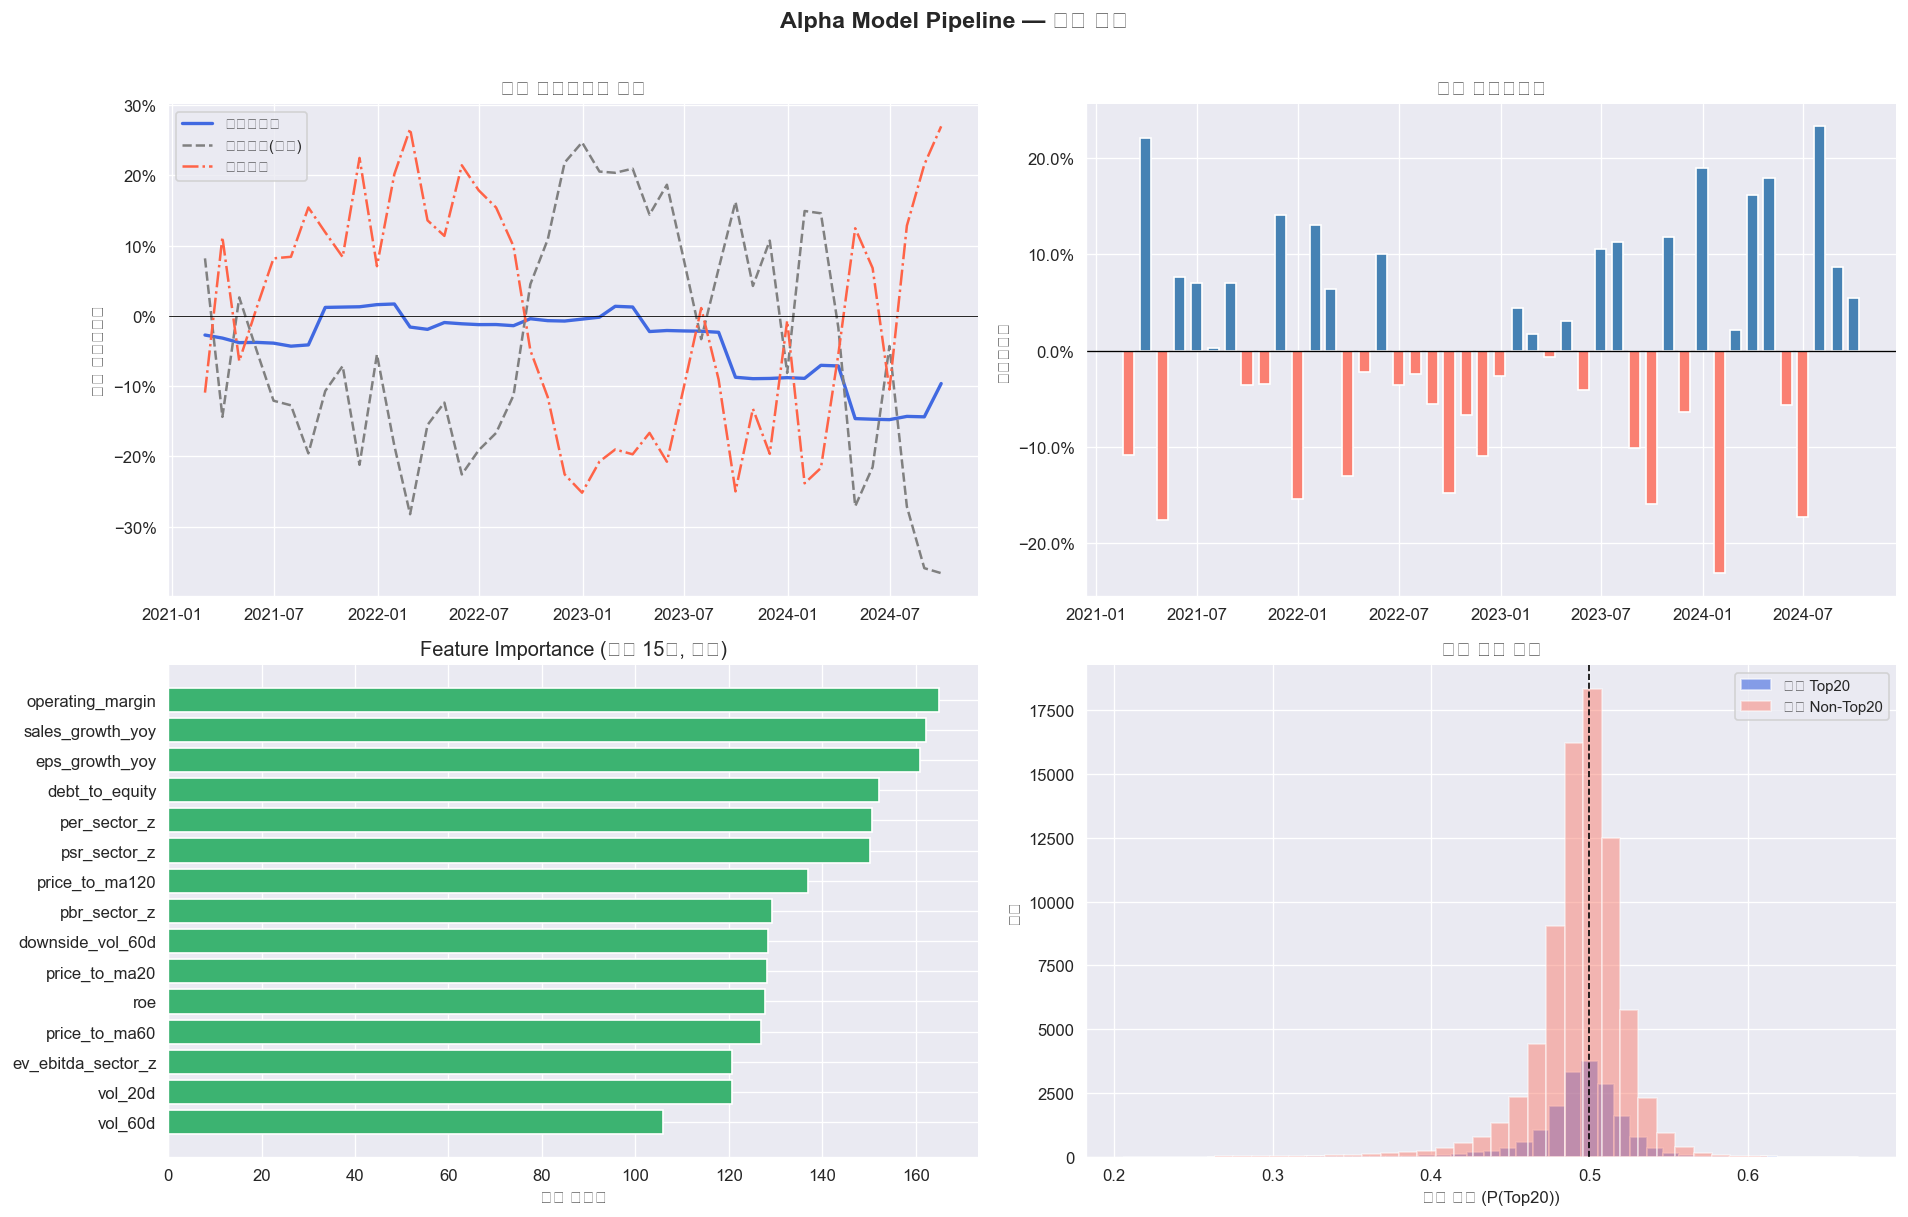

  ✅ 그래프 저장: alpha_model_results.png

[월별 예측 결과 샘플 (상위 10행)]
        date ticker       sector     proba  pred  actual  realized_alpha_3m  \
0 2021-02-28  T0245       Energy  0.621826     1       0           0.003637   
1 2021-02-28  T1717  Health Care  0.620075     1       0          -0.032975   
2 2021-02-28  T0080   Financials  0.619584     1       0          -0.043942   
3 2021-02-28  T1158   Technology  0.609559     1       0          -0.070101   
4 2021-02-28  T0791       Energy  0.591277     1       0          -0.031285   
5 2021-02-28  T0098   Financials  0.591080     1       0          -0.031846   
6 2021-02-28  T0871  Health Care  0.573651     1       0          -0.043221   
7 2021-02-28  T1219  Health Care  0.568534     1       0           0.017225   
8 2021-02-28  T0282   Technology  0.568394     1       1           0.018618   
9 2021-02-28  T0086   Financials  0.568047     1       0          -0.058294   

        price  
0   63.626955  
1  384.577268  
2  530.593285  
3  121

In [19]:
# ─────────────────────────────────────────────────────────────────────
# Cell 4  파이프라인 실행
# ─────────────────────────────────────────────────────────────────────

# ── 파라미터 설정 ─────────────────────────────────────────────────────
pipeline = AlphaModelPipeline(
    n_tickers        = N_TICKERS,   # Cell 2에서 설정한 종목 수
    horizon          = 3,            # t+3개월 예측
    top_pct          = 0.20,         # 상위 20%
    min_train_months = 36,           # 최소 학습 기간 36개월
    model_type       = 'lgbm',       # 'lgbm' 또는 'xgb'
    transaction_cost = 0.001,        # 10bp
    random_state     = 42,
)

# ── 전체 파이프라인 실행 ───────────────────────────────────────────────
metrics = pipeline.run(df_raw)

# ── 월별 예측 결과 DataFrame 출력 ─────────────────────────────────────
print('\n[월별 예측 결과 샘플 (상위 10행)]')
print(
    pipeline.df_predictions_
    .sort_values(['date','proba'], ascending=[True, False])
    .head(10)
    .reset_index(drop=True)
)

# ── 포트폴리오 월별 수익률 DataFrame 출력 ─────────────────────────────
print('\n[포트폴리오 월별 수익률 샘플 (상위 10행)]')
print(
    pipeline.df_portfolio_.head(10)
)

---
## Cell 5 — 모델 변경 및 개별 메서드 실행 예시
> LightGBM → XGBoost로 전환하거나, 파라미터를 바꿔서 실험할 때 사용합니다.

In [20]:
# ─────────────────────────────────────────────────────────────────────
# Cell 5  XGBoost 모델로 전환 실험 (선택 실행)
# ─────────────────────────────────────────────────────────────────────

pipeline_xgb = AlphaModelPipeline(
    n_tickers        = N_TICKERS,
    horizon          = 3,
    top_pct          = 0.20,
    min_train_months = 36,
    model_type       = 'xgb',        # ← XGBoost 사용
    transaction_cost = 0.001,
    random_state     = 42,
)

print('▶ XGBoost 파이프라인 실행 중...')
pipeline_xgb.preprocess(df_raw)
pipeline_xgb.run_walkforward()
pipeline_xgb.backtest()
metrics_xgb = pipeline_xgb.evaluate()

# ── LGBM vs XGB 비교 ──────────────────────────────────────────────────
print('\n[LGBM vs XGB 성과 비교]')
compare = pd.DataFrame({
    'LGBM' : metrics,
    'XGB'  : metrics_xgb,
}).T[['precision','recall','f1','auc','cagr','sharpe','mdd']]
compare.columns = ['Precision','Recall','F1','AUC','CAGR','Sharpe','MDD']
print(compare.round(4))

▶ XGBoost 파이프라인 실행 중...
▶ [전처리] 시작...
  → 전처리 완료: 166,000행  피처 수: 33개
  → 유효 날짜 범위: 2018-02-28 ~ 2024-12-31
▶ [Walk-forward] 시작...
  [2021-02-28] 학습:72,000행(+:14400) → 예측:2000종목  AUC=0.697
  [2021-03-31] 학습:74,000행(+:14800) → 예측:2000종목  AUC=0.696
  [2021-04-30] 학습:76,000행(+:15200) → 예측:2000종목  AUC=0.698
  [2021-05-31] 학습:78,000행(+:15600) → 예측:2000종목  AUC=0.688
  [2021-06-30] 학습:80,000행(+:16000) → 예측:2000종목  AUC=0.691
  [2021-07-31] 학습:82,000행(+:16400) → 예측:2000종목  AUC=0.691
  [2021-08-31] 학습:84,000행(+:16800) → 예측:2000종목  AUC=0.687
  [2021-09-30] 학습:86,000행(+:17200) → 예측:2000종목  AUC=0.685
  [2021-10-31] 학습:88,000행(+:17600) → 예측:2000종목  AUC=0.682
  [2021-11-30] 학습:90,000행(+:18000) → 예측:2000종목  AUC=0.681
  [2021-12-31] 학습:92,000행(+:18400) → 예측:2000종목  AUC=0.680
  [2022-01-31] 학습:94,000행(+:18800) → 예측:2000종목  AUC=0.677
  [2022-02-28] 학습:96,000행(+:19200) → 예측:2000종목  AUC=0.678
  [2022-03-31] 학습:98,000행(+:19600) → 예측:2000종목  AUC=0.680
  [2022-04-30] 학습:100,000행(+:20000) → 예측:2000종목  AUC=0.67